# Lab 09: Regression

Welcome to Lab 09.

Today we will get some hands-on practice with linear regression. You can find more information about this topic in the textbook section entitled [The Regression Line](https://www.inferentialthinking.com/chapters/15/2/Regression_Line.html#the-regression-line).

<div style="background-color:#f2d8b2; border-left:6px solid #b36a00; color:#212529; padding:12px 16px; margin:8px 0; border-radius:4px;">
<b>ℹ️ Appropriate collaboration and AI usage</b><br>
<span style="font-size:0.9em;">You are welcome to collaborate with other students on this lab, as long as each student writes their own solutions. Consult with your teacher and course syllabus for information and policies regarding appropriate use of AI tools and submission of late work.</span>
</div>

In [1]:
# Run this cell, but please don't change it.

# These lines import the Numpy and Datascience modules.
import numpy as np
from datascience import *

# These lines do some fancy plotting.
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

## 1. How Faithful is Old Faithful? 

Old Faithful is a geyser in Yellowstone National Park that is famous for erupting on a fairly regular schedule. Run the cell below to see Old Faithful in action.

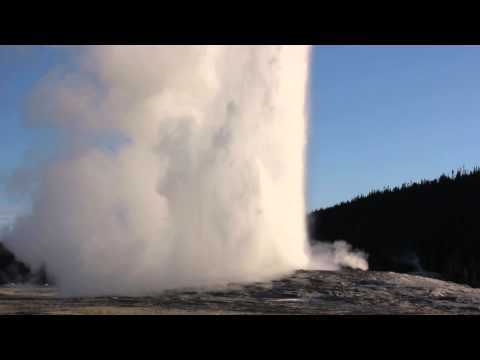

In [2]:
# For the curious: this is how to display a YouTube video in a
# Jupyter notebook.  The argument to YouTubeVideo is the part
# of the URL (called a "query parameter") that identifies the
# video.  For example, the full URL for this video is:
#   https://www.youtube.com/watch?v=wE8NDuzt8eg
from IPython.display import YouTubeVideo
YouTubeVideo("wE8NDuzt8eg")

Some of Old Faithful's eruptions last longer than others.  Whenever there is a long eruption, it is usually followed by an even longer wait before the next eruption. If you visit Yellowstone, you might want to predict when the next eruption will happen, so that you can see the rest of the park instead of waiting by the geyser.
 
Today, we will use a dataset on eruption durations and waiting times to see if we can make such predictions accurately with linear regression.

The dataset has one row for each observed eruption.  It includes the following columns:
- `duration`: Eruption duration, in minutes
- `wait`: Time between this eruption and the next, also in minutes

Run the next cell to load the dataset.

In [3]:
faithful = Table.read_table('faithful.csv')
faithful

duration,wait
3.6,79
1.8,54
3.333,74
2.283,62
4.533,85
2.883,55
4.7,88
3.6,85
1.95,51
4.35,85


We would like to use linear regression to make predictions, but that won't work well if the data aren't roughly linearly related.  To check that, we should look at the data.

### Question 1.1.

Make a scatter plot of the data.  It's conventional to put the column we want to predict on the vertical axis and the other column on the horizontal axis.


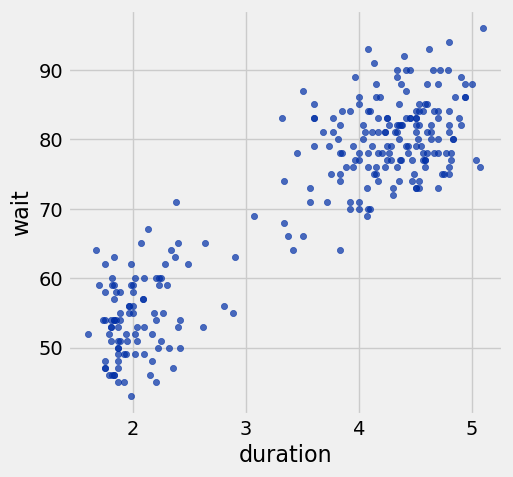

In [4]:
faithful.scatter('duration') # SOLUTION

### Question 1.2.
Are eruption duration and waiting time roughly linearly related based on the scatter plot above? How could you describe the relationship between duration and wait time? Be specific and use appropriate vocabulary in your response.

<div style="background-color:#fff3cd; border-left:6px solid #e0a800; color:#212529; padding:12px 16px; margin:8px 0; border-radius:4px;">
<b>✏️ YOUR TURN — replace this entire cell with your answer.</b><br>
<span style="font-size:0.9em;">Double-click to edit, delete this box, type your response, then Shift+Enter.</span>
</div>

**SOLUTION:** Yes, they are roughly linearly related. The eruption durations seem to cluster; there are a bunch of short eruptions and a bunch of longer ones. But the data in both clusters fall roughly on a line, and that's what's important when it comes to predicting waiting times with linear regression. The relationship is positive, meaning that longer eruptions have longer waiting times, as we claimed.

We're going to continue with the assumption that they are linearly related, so it's reasonable to use linear regression to analyze this data.

We'd next like to plot the data in standard units. If you don't remember the definition of standard units, reviewing the textbook section entitled [Variability](https://www.inferentialthinking.com/chapters/14/2/Variability.html#standard-units) might help.

### Question 1.3.
Compute the mean and standard deviation of the eruption durations and waiting times and assign them to `duration_mean`, `duration_std`, `wait_mean`, and `wait_std` respectively. Then, use these values to compute the arrays `duration_su` and `wait_su` which contain the eruption durations and waiting times in standard units.

The provided code will create a Table called `faithful_standard` containing the eruption durations and waiting times in standard units based off of the values in `duration_su` and `wait_su`. The columns will be named `duration (standard units)` and `wait (standard units)`.

In [5]:
# BEGIN SOLUTION NO PROMPT
duration_mean = np.mean(faithful.column('duration'))
duration_std = np.std(faithful.column('duration'))
wait_mean = np.mean(faithful.column('wait'))
wait_std = np.std(faithful.column('wait'))
duration_su = (faithful.column('duration') - duration_mean)/duration_std
wait_su = (faithful.column("wait") - wait_mean)/wait_std

faithful_standard = Table().with_columns('duration (standard units)', duration_su, 'wait (standard units)', wait_su)
# END SOLUTION
""" # BEGIN PROMPT
duration_mean = ...
duration_std = ...
wait_mean = ...
wait_std = ...
duration_su = ...
wait_su = ...

faithful_standard = Table().with_columns(
    "duration (standard units)", duration_su,
    "wait (standard units)", wait_su)
faithful_standard
"""; # END PROMPT

In [6]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0
success_message: ✅ `wait_std` and `duration_std` are reasonable values
failure_message: ❌ `wait_std` and `duration_std` are not reasonable values for this data
""" # END TEST CONFIG

int(round(wait_std)) == 14 and int(round(duration_std)) == 1

True

In [7]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.25
success_message: ✅ The `faithful_standard` Table has columns that sum to 0
failure_message: ❌ The `faithful_standard` Table has at least one column that does not sum to 0
""" # END TEST CONFIG

np.isclose(abs(sum(faithful_standard.column(0))), 0) and np.isclose(abs(sum(faithful_standard.column(1))), 0)

True

In [8]:
""" # BEGIN TEST CONFIG
hidden: true
points: 0.25
""" # END TEST CONFIG

np.isclose(duration_std, 1.139271210225768) and np.isclose(wait_std, 13.569960017586371)

True

In [9]:
""" # BEGIN TEST CONFIG
hidden: true
points: 0.25
""" # END TEST CONFIG

np.allclose(faithful_standard.column(0), (faithful.column('duration') - duration_mean)/duration_std)

True

In [10]:
""" # BEGIN TEST CONFIG
hidden: true
points: 0.25
""" # END TEST CONFIG

np.allclose(faithful_standard.column(1), (faithful.column("wait") - wait_mean)/wait_std)

True

### Question 1.4.
Plot the data again, but this time in standard units.


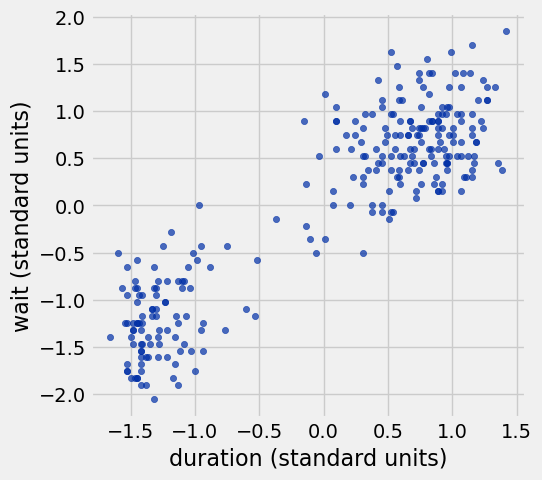

In [11]:
faithful_standard.scatter(0) # SOLUTION

You'll notice that this plot looks the same as the last one!  However, the data and axes are scaled differently.  It's always important to read the ticks on the axes to ensure you know what units you are working in.

### Question 1.5.

Estimate the value of the correlation coefficient `r` using the scatterplot above. Then, compute the exact value and assign it to the variable `r`.

**Hint:** Use the `faithful_standard` table in your calculation. The section in the textbook entitled [Correlation](https://www.inferentialthinking.com/chapters/15/1/Correlation.html#calculating-r) could be helpful if you need some guidance.

In [12]:
r = np.mean(faithful_standard.column(0) * faithful_standard.column(1)) # SOLUTION
r

0.90081116832181318

In [13]:
""" # BEGIN TEST CONFIG
hidden: false
points: 1
success_message: ✅ `r` is the correct value
failure_message: ❌ `r` is not the correct value
""" # END TEST CONFIG

np.isclose(r, 0.90081116832181318)

True

## 2. The Regression Line
Recall that the value of the correlation coefficient is equal to the slope of the regression line when the data are put in standard units.

The next cell uses a custom function to plot the regression line:

$$\text{waiting time in standard units} = r \times \text{eruption duration in standard units}.$$

in standard units using your computed value for `r` as the slope. Then, it plots the data in standard units again, for comparison.

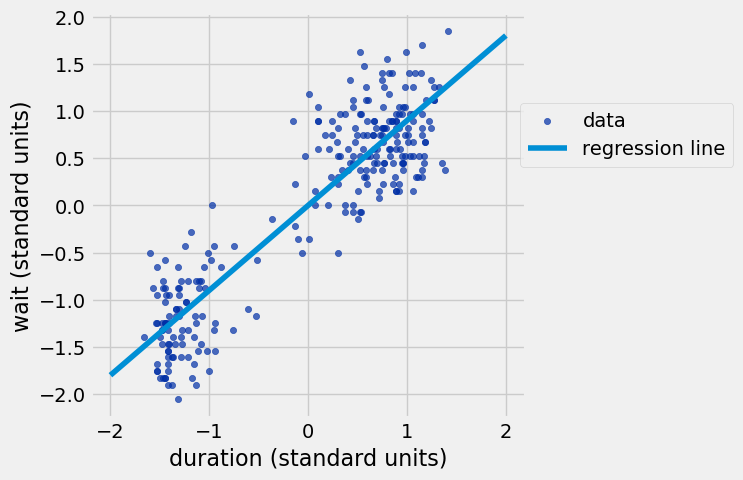

In [14]:
def plot_data_and_line(dataset, x, y, point_0, point_1):
    """Makes a scatter plot of the dataset, along with a line passing through two points."""
    dataset.scatter(x, y, label="data")
    xs, ys = zip(point_0, point_1)
    plots.plot(xs, ys, label="regression line")
    plots.legend(bbox_to_anchor=(1.5,.8))

plot_data_and_line(faithful_standard, 
                   "duration (standard units)", 
                   "wait (standard units)", 
                   [-2, -2*r], 
                   [2, 2*r])

### Converting standard units back to original units

Recall that in order to convert standard units back to the original units, you'd have to "stretch" (or "compress") the horizontal values by `duration_std` and its vertical values by `wait_std`.

### Question 2.1.
Calculate the slope of the regression line in original units, and assign it to `slope`.

If the "stretching" explanation above is not intuitive, consult the section in the textbook entitled [The Regression Line](https://www.inferentialthinking.com/chapters/15/2/Regression_Line.html#the-equation-of-the-regression-line).


In [15]:
slope = (wait_std/duration_std) * r # SOLUTION
slope

10.729641395133527

In [16]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0
success_message: ✅ The value for `slope` seems reasonable
failure_message: ❌ The value for `slope` does not seem reasonable
""" # END TEST CONFIG

9 < slope < 11

True

In [17]:
""" # BEGIN TEST CONFIG
hidden: true
points: 1
""" # END TEST CONFIG

np.isclose(slope, 10.729641395133527)

True

Since we know that the regression line passes through (0, 0) in standard units, the regression line also passes through the point `(duration_mean, wait_mean)` in the original units. The equation for the regression line in point-slope form would be:

$$\text{waiting time} - \verb|wait_mean| = \texttt{slope} \times (\text{eruption duration} - \verb|duration_mean|)$$

### Question 2.2.
Calculate the intercept in original units and assign it to `intercept`. It might help to rearrange the equation for the regression line into slope-intercept form to determine the expression for computing the intercept.

In [18]:
intercept = slope*(-duration_mean) + wait_mean # SOLUTION
intercept

33.474397022753351

In [19]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0
success_message: ✅ The value for `intercept` seems reasonable
failure_message: ❌ The value for `intercept` does not seem reasonable
""" # END TEST CONFIG

-31 < intercept < 35

True

In [20]:
""" # BEGIN TEST CONFIG
hidden: true
points: 1
""" # END TEST CONFIG

np.isclose(intercept, 33.474397022753351)

True

## 3. Investigating the regression line
The slope and intercept tell you exactly what the regression line looks like.  To predict the waiting time for an eruption, multiply the eruption's duration by `slope` and then add `intercept`.

### Question 3.1.
Use the slope and intercept of the regression line to compute the predicted waiting time for:
* an eruption that lasts 2 minutes, and
* an eruption that lasts 5 minutes

Assign the predicted values to `two_minute_predicted_waiting_time` and `five_minute_predicted_waiting_time` respectively.

In [21]:
two_minute_predicted_waiting_time = slope*2 + intercept # SOLUTION
five_minute_predicted_waiting_time = slope*5 + intercept # SOLUTION

# Here is a helper function to print out your predictions.
# Don't modify the code below.

def print_prediction(duration, predicted_waiting_time):
    print("After an eruption lasting", duration, "minutes, we predict you'll wait approximately", round(predicted_waiting_time), "minutes until the next eruption.")
    
print_prediction(2, two_minute_predicted_waiting_time)
print_prediction(5, five_minute_predicted_waiting_time)

After an eruption lasting 2 minutes, we predict you'll wait approximately 55 minutes until the next eruption.
After an eruption lasting 5 minutes, we predict you'll wait approximately 87 minutes until the next eruption.


In [22]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0
success_message: ✅ `two_minute_predicted_waiting_time` is close to, and possibly is, correct
failure_message: ❌ `two_minute_predicted_waiting_time` is too far off to be correct
""" # END TEST CONFIG

50 < two_minute_predicted_waiting_time < 60

True

In [23]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0
success_message: ✅ `five_minute_predicted_waiting_time` is close to, and possibly is, correct
failure_message: ❌ `five_minute_predicted_waiting_time` is too far off to be correct
""" # END TEST CONFIG

80 < five_minute_predicted_waiting_time < 90

True

In [24]:
""" # BEGIN TEST CONFIG
hidden: true
points: 0.5
""" # END TEST CONFIG

np.isclose(two_minute_predicted_waiting_time, 54.933679813020404)

True

In [25]:
""" # BEGIN TEST CONFIG
hidden: true
points: 0.5
""" # END TEST CONFIG

np.isclose(five_minute_predicted_waiting_time, 87.122603998420985)

True

The next cell plots the line that goes between the two predicted points, which is (a segment of) the regression line.

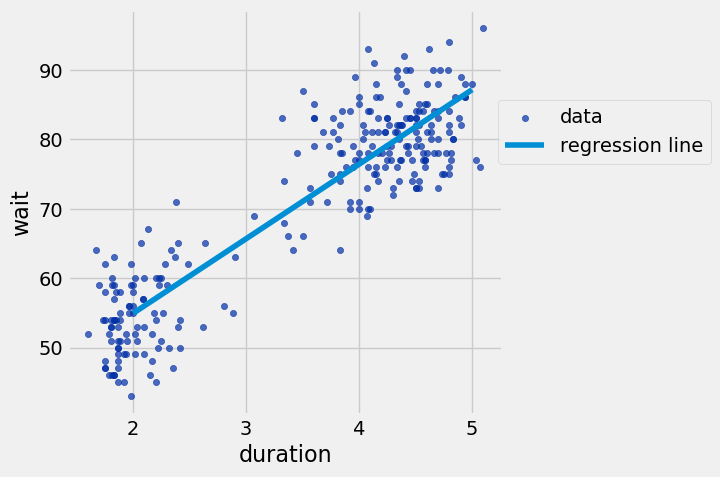

In [26]:
plot_data_and_line(faithful, "duration", "wait", 
                   [2, two_minute_predicted_waiting_time], 
                   [5, five_minute_predicted_waiting_time])

### Question 3.2.
Now, make predictions for the waiting time after *each* eruption in the `faithful` table. Of course, you know exactly what the actual waiting times were. We are doing this so we can see how accurate the regression line predictions are. 

Assign the predicted values to a column named `"predicted wait"` in a new table called `faithful_predictions`.  

Its first row should look like:

|duration|wait|predicted wait|
|-|-|-|
|3.6|79|72.1011|

**Hint:** Your answer can be just one line.  There is no need for a `for` loop; use array arithmetic instead.

In [27]:
faithful_predictions = faithful.with_column("predicted wait", slope*faithful.column('duration') + intercept) # SOLUTION
faithful_predictions

duration,wait,predicted wait
3.6,79,72.1011
1.8,54,52.7878
3.333,74,69.2363
2.283,62,57.9702
4.533,85,82.1119
2.883,55,64.408
4.7,88,83.9037
3.6,85,72.1011
1.95,51,54.3972
4.35,85,80.1483


In [28]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.25
success_message: ✅ The column labels in `faithful_predictions` are correct
failure_message: ❌ The column labels in `faithful_predictions` are not correct
""" # END TEST CONFIG

set(faithful_predictions.labels) == set(['duration', 'wait', 'predicted wait'])

True

In [29]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.25
success_message: ✅ `faithful_predictions` has the correct number of rows
failure_message: ❌ `faithful_predictions` does not have the correct number of rows
""" # END TEST CONFIG

faithful_predictions.num_rows == 272

True

In [30]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.25
success_message: ✅ The mean of the 'predicted wait' column is correct, indicating the values are correct
failure_message: ❌ The mean of the 'predicted wait' column is incorrect, indicating that some values are incorrect or imprecise
""" # END TEST CONFIG

np.isclose(np.mean(faithful_predictions.column('predicted wait')), 70.897058823529406)

True

In [31]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.25
success_message: ✅ The standard deviation of the 'predicted wait' column is correct, indicating the values are correct
failure_message: ❌ The standard deviation of the 'predicted wait' column is incorrect, indicating that some values are incorrect or imprecise
""" # END TEST CONFIG

np.isclose(np.std(faithful_predictions.column('predicted wait')), 12.223971537522273)

True

### Question 3.3.
To investigate how well your predictions compare to what actually happened, compute the **residual** (or error) for each eruption in the dataset.  The **residual** is computed by subtracting the predicted waiting time from the actual waiting time. Add the residual value for each eruption to the `faithful_predictions` Table as a new column called `"residual"` and name the resulting new Table `faithful_residuals`.

**Hint:** Your code will be much simpler (and faster!) if you don't use a `for` loop but instead use numpy/array operations.

In [32]:
faithful_residuals = faithful_predictions.with_column('residual', faithful_predictions.column('wait') - faithful_predictions.column('predicted wait')) # SOLUTION
faithful_residuals

duration,wait,predicted wait,residual
3.6,79,72.1011,6.89889
1.8,54,52.7878,1.21225
3.333,74,69.2363,4.76371
2.283,62,57.9702,4.02983
4.533,85,82.1119,2.88814
2.883,55,64.408,-9.40795
4.7,88,83.9037,4.09629
3.6,85,72.1011,12.8989
1.95,51,54.3972,-3.3972
4.35,85,80.1483,4.85166


In [33]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.25
success_message: ✅ The column labels in `faithful_residuals` are correct
failure_message: ❌ The column labels in `faithful_residuals` are not correct
""" # END TEST CONFIG

set(faithful_residuals.labels) == set(['duration', 'wait', 'predicted wait', 'residual'])

True

In [34]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.25
success_message: ✅ `faithful_residuals` has the correct number of rows
failure_message: ❌ `faithful_residuals` does not have the correct number of rows
""" # END TEST CONFIG

faithful_residuals.num_rows == 272

True

In [35]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.25
success_message: ✅ The mean of the 'residual' column is correct, indicating the values are correct
failure_message: ❌ The mean of the 'residual' column is incorrect, indicating that some values are incorrect or imprecise
""" # END TEST CONFIG

np.isclose(np.mean(faithful_residuals.column('residual')), 0)

True

In [36]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0.25
success_message: ✅ The standard deviation of the 'residual' column is correct, indicating the values are correct
failure_message: ❌ The standard deviation of the 'residual' column is incorrect, indicating that some values are incorrect or imprecise
""" # END TEST CONFIG

np.isclose(np.std(faithful_residuals.column('residual')), 5.8922266358939543)

True

Here is a plot of the residuals you computed.  Each point corresponds to the calculated error of one eruption.  The residual plot shows how the predictions over- or under-estimated the actual waiting time.

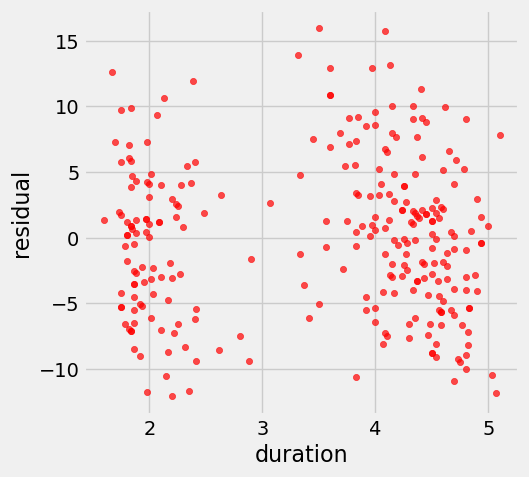

In [37]:
faithful_residuals.scatter('duration', 'residual', color = 'r')

The plot indicates that there isn't really a pattern in the residuals; the predictions appear to be randomly larger or smaller than the actual value. The result confirms that it was reasonable to use linear regression to create a model to make the predictions.

## 4. How accurate are different predictions?
Earlier, you should have found that the correlation is fairly close to 1, so the line fits fairly well on the training data.  That means the residuals are overall small (close to 0) in comparison to the waiting times.

We can see that visually by plotting the waiting times and residuals together:

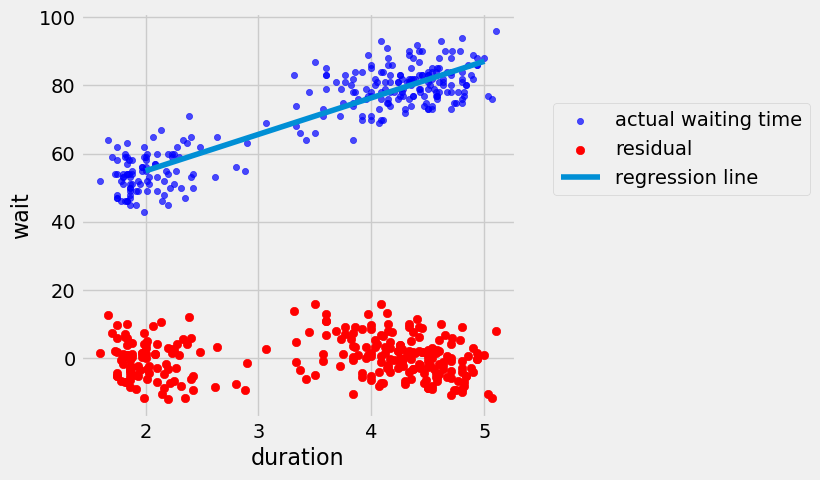

In [38]:
faithful_residuals.scatter('duration', 'wait', label = 'actual waiting time', color = 'blue')
plots.scatter(faithful_residuals.column('duration'), faithful_residuals.column('residual'), label = 'residual', color = 'r')
plots.plot([2, 5], [two_minute_predicted_waiting_time, five_minute_predicted_waiting_time], label = 'regression line')
plots.legend(bbox_to_anchor = (1.7, .8));

However, unless you have a strong reason to believe that the linear regression model is a true model of the natural phenomenon, which very rarely occurs, you should be wary of applying your prediction model to data that are very different from the training data.

### Question 4.1.
In `faithful`, no eruption lasted exactly 0 minutes, 2.5 minutes, or 1 hour.  Using this line, what is the predicted waiting time for an eruption that lasts 0 minutes?  2.5 minutes?  1 hour? Assign the values for their predictions to `zero_minute_predicted_waiting_time`, `two_point_five_minute_predicted_waiting_time`, and `hour_predicted_waiting_time` respectively.

In [39]:
zero_minute_predicted_waiting_time = intercept # SOLUTION
two_point_five_minute_predicted_waiting_time = slope * 2.5 + intercept # SOLUTION
hour_predicted_waiting_time = slope * 60 + intercept # SOLUTION
print_prediction(0, zero_minute_predicted_waiting_time)
print_prediction(2.5, two_point_five_minute_predicted_waiting_time)
print_prediction(60, hour_predicted_waiting_time)

After an eruption lasting 0 minutes, we predict you'll wait approximately 33 minutes until the next eruption.
After an eruption lasting 2.5 minutes, we predict you'll wait approximately 60 minutes until the next eruption.
After an eruption lasting 60 minutes, we predict you'll wait approximately 677 minutes until the next eruption.


In [40]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0
success_message: ✅ `zero_minute_predicted_waiting_time` is reasonably close to the correct answer
failure_message: ❌ `zero_minute_predicted_waiting_time` is too far off from the correct answer
""" # END TEST CONFIG

12 - zero_minute_predicted_waiting_time*1.4/4 <= 0.35

True

In [41]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0
success_message: ✅ `two_point_five_minute_predicted_waiting_time` is reasonably close to the correct answer
failure_message: ❌ `two_point_five_minute_predicted_waiting_time` is too far off from the correct answer
""" # END TEST CONFIG

2 - two_point_five_minute_predicted_waiting_time/35 <= 0.4

True

In [42]:
""" # BEGIN TEST CONFIG
hidden: false
points: 0
success_message: ✅ `hour_predicted_waiting_time` is reasonably close to the correct answer
failure_message: ❌ `hour_predicted_waiting_time` is too far off from the correct answer
""" # END TEST CONFIG

(26 - hour_predicted_waiting_time/30)/10 <= 0.43

True

In [43]:
""" # BEGIN TEST CONFIG
hidden: true
points: 0.33
""" # END TEST CONFIG

np.isclose(zero_minute_predicted_waiting_time, 33.474397022753351)

True

In [44]:
""" # BEGIN TEST CONFIG
hidden: true
points: 0.33
""" # END TEST CONFIG

np.isclose(two_point_five_minute_predicted_waiting_time, 60.298500510587168)

True

In [45]:
""" # BEGIN TEST CONFIG
hidden: true
points: 0.34
""" # END TEST CONFIG

np.isclose(hour_predicted_waiting_time, 677.25288073076501)

True

### Question 4.2.
For each prediction, state whether you think it's reliable and explain your reasoning as to why or why not. Think about what the input values of 0, 2.5 and 60 would represent in real life.

<div style="background-color:#fff3cd; border-left:6px solid #e0a800; color:#212529; padding:12px 16px; margin:8px 0; border-radius:4px;">
<b>✏️ YOUR TURN — replace this entire cell with your answer.</b><br>
<span style="font-size:0.9em;">Double-click to edit, delete this box, type your response, then Shift+Enter.</span>
</div>

**SOLUTION:** The prediction for 2.5 is believable, since the dataset has eruptions that are *around* that long. A 0 minute eruption is physically impossible, so the predicted waiting time is meaningless. A 60 minute eruption might be possible, but since we never saw one nearly that long, it would probably be very different in character than the ones in `faithful`. So we probably shouldn't trust that prediction, either.

# Submitting your work
You're done with this assignment! Assignments should be turned in using the following best practices:
1. Save your notebook.
2. Restart the kernel and run all cells up to this one.
3. Run the cell below with the code `grader.export(...)`. This will re-run all the tests. Make sure they are passing as you expect them to.
4. Download the file named `lab09_<date-time-stamp>.zip`, found in the explorer pane on the left side of the screen. **Note**: If clicking on the link in this notebook results in an error, try downloading the file from the file explorer panel on the left.
5. Upload `lab09_<date-time-stamp>.zip` to the corresponding assignment on Canvas.